### Временные ряды

**Задание 1**


Импортируйте необходимые библиотеки для работы с временными рядами и их визуализацией

In [8]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm.notebook import tqdm

Задание 2


*   Импортируйте датасет, содержащий временной ряд. Отделите тестовую часть от тренировочной, если это изначально не сделано. Проведите предобработку данных.
*   Выведите графики временного ряда, для которого собираетесь делать предсказание.
*   Проедите STL decomposition исследуемого временного ряда.
*   Добавьте признаки в вашу модель.
*   Получите предсказание, испольуя модели скользящего среднего, экспоненциального скользящего среднего, ARIMA для разных значений параметров моделей.
*   Сравните результат, сделав предсказание на тренировочной части датасета
*   Примените две на выбор модели регрессии для получения предсказания. Выведите график результата.






In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

train = pd.read_csv('DailyDelhiClimateTrain.csv')
test = pd.read_csv('DailyDelhiClimateTest.csv')

train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
train.set_index('date', inplace=True)
test.set_index('date', inplace=True)

ts_train = train['meantemp']
ts_test = test['meantemp']

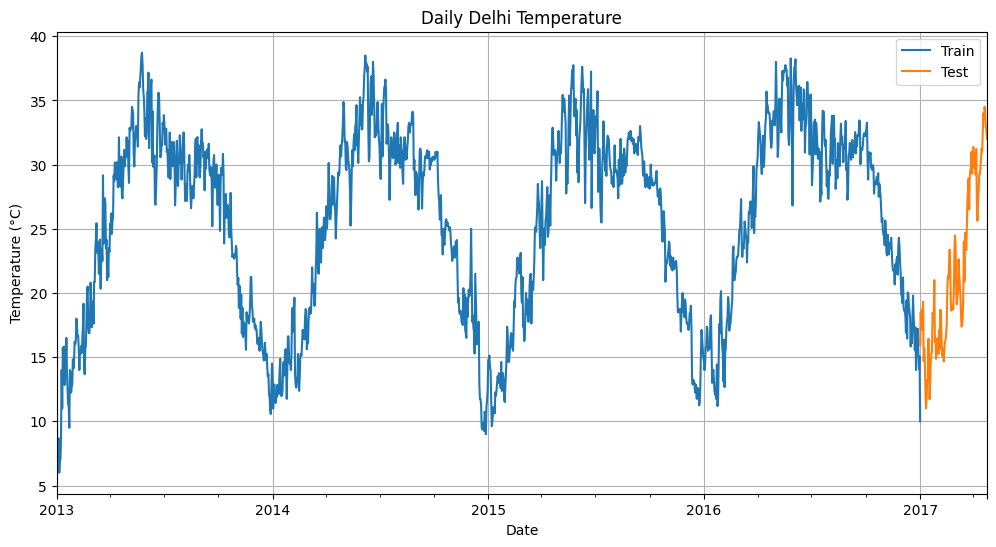

In [10]:
plt.figure(figsize=(12, 6))
ts_train.plot(label='Train')
ts_test.plot(label='Test')
plt.title('Daily Delhi Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid()
plt.show()

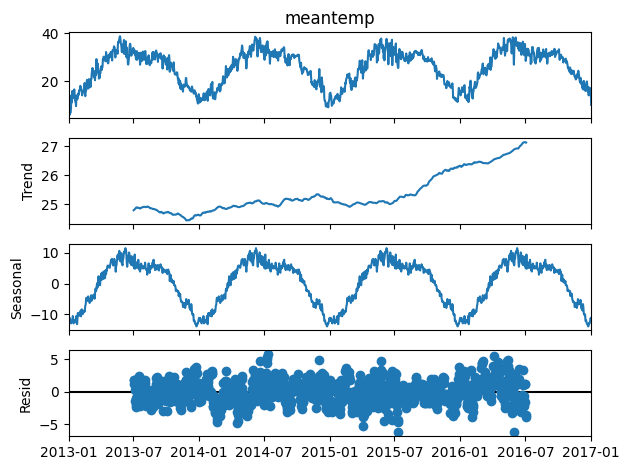

In [11]:
result = seasonal_decompose(ts_train, model='additive', period=365)
result.plot()
plt.tight_layout()
plt.show()

In [12]:
# Создаем DataFrame с признаками для моделей регрессии
def create_features(df):
    df = df.copy()
    df['dayofyear'] = df.index.dayofyear
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    return df

train_features = create_features(ts_train.to_frame())
test_features = create_features(ts_test.to_frame())

X_train = train_features.drop('meantemp', axis=1)
y_train = train_features['meantemp']
X_test = test_features.drop('meantemp', axis=1)
y_test = test_features['meantemp']

Доп: 1. Изменить размеры окна и показать на одном графике результат. 2. Добавить SARIMA


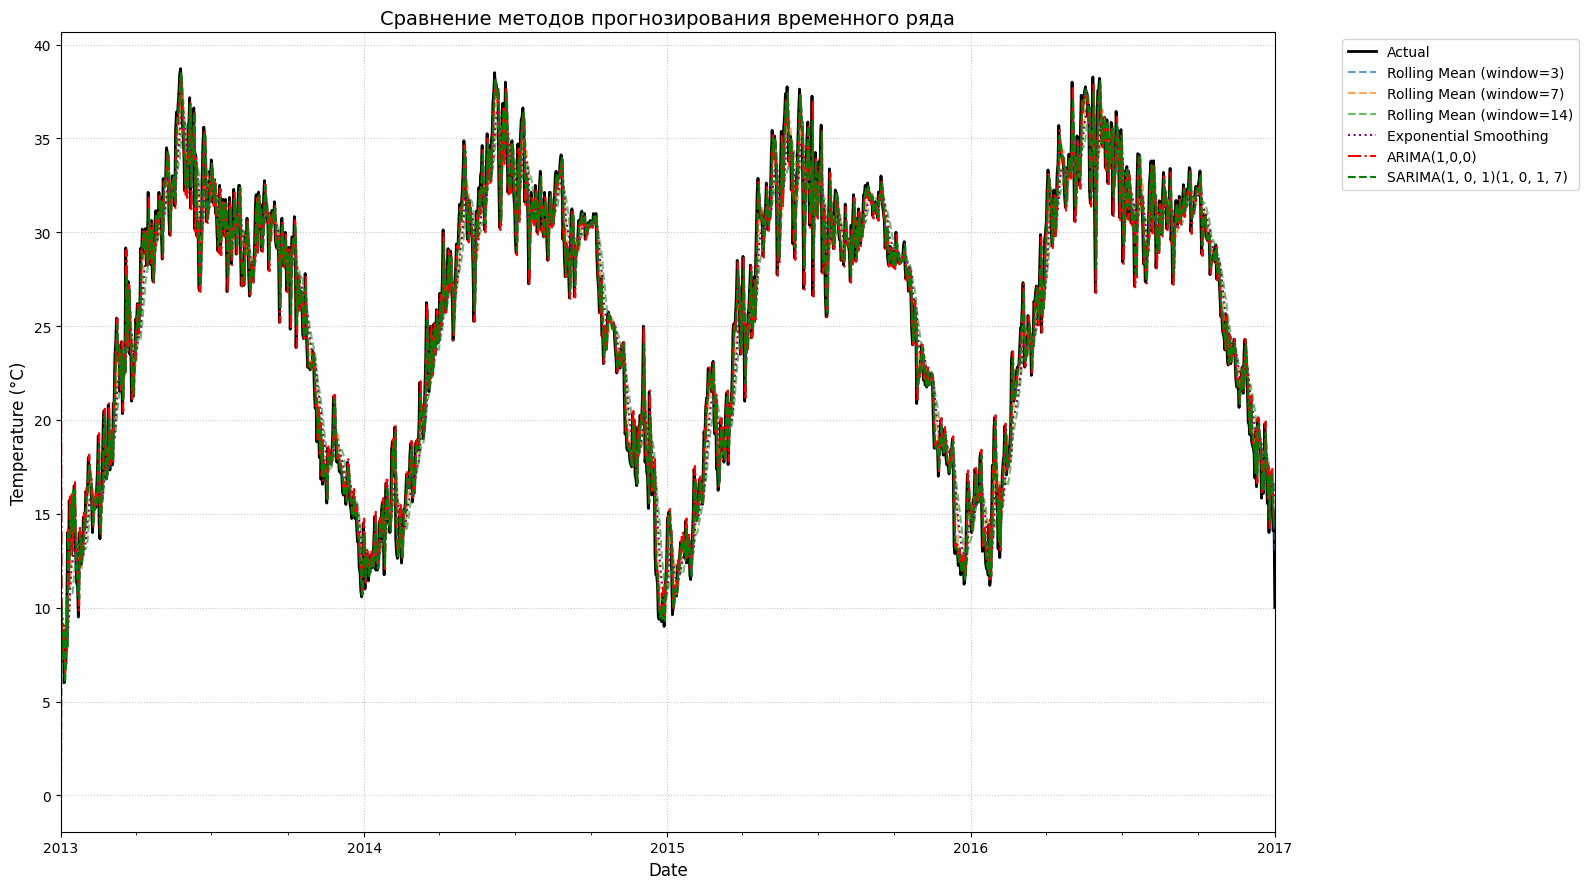


Ошибки прогнозирования (MSE):
Rolling Mean (window=3) MSE: 1.3498
Rolling Mean (window=7) MSE: 2.9844
Rolling Mean (window=14) MSE: 4.4356
Exponential Smoothing MSE: 3.8174
ARIMA MSE: 2.9016
SARIMA MSE: 2.7671


In [16]:
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Скользящее среднее с разными окнами
window_sizes = [3, 7, 14]  # Разные размеры окон для сравнения
rolling_preds = {}
for window in window_sizes:
    rolling_preds[window] = ts_train.rolling(window=window).mean().iloc[window:]

# Экспоненциальное сглаживание
model_exp = SimpleExpSmoothing(ts_train)
fit_exp = model_exp.fit(smoothing_level=0.2)
exp_pred = fit_exp.fittedvalues

# ARIMA (несезонная)
model_arima = ARIMA(ts_train, order=(1, 0, 0))  # Порядки (p,d,q)
fit_arima = model_arima.fit()
arima_pred = fit_arima.predict(start=ts_train.index[0], end=ts_train.index[-1], typ='levels')

# SARIMA (сезонная модель)
# Порядки модели: (p,d,q) - несезонные компоненты
# (P,D,Q,s) - сезонные компоненты, где s - длина сезона (например, 7 для недельной сезонности)
sarima_order = (1, 0, 1)          # Несезонные параметры (p,d,q)
seasonal_order = (1, 0, 1, 7)      # Сезонные параметры (P,D,Q,s) где s=7 дней

# Создаем и обучаем SARIMA модель
model_sarima = SARIMAX(ts_train, 
                      order=sarima_order, 
                      seasonal_order=seasonal_order,
                      enforce_stationarity=False,
                      enforce_invertibility=False)

fit_sarima = model_sarima.fit(disp=False)  # disp=False отключает вывод итераций обучения
sarima_pred = fit_sarima.get_prediction(start=ts_train.index[0], 
                                       end=ts_train.index[-1]).predicted_mean

# Визуализация на тренировочных данных
plt.figure(figsize=(16, 9))
ts_train.plot(label='Actual', linewidth=2, color='black')

# Добавляем все скользящие средние с разными окнами
for window, pred in rolling_preds.items():
    pred.plot(label=f'Rolling Mean (window={window})', linestyle='--', alpha=0.7)

exp_pred.plot(label='Exponential Smoothing', linestyle=':', color='purple')
arima_pred.plot(label='ARIMA(1,0,0)', linestyle='-.', color='red')
sarima_pred.plot(label=f'SARIMA{sarima_order}{seasonal_order}', linestyle='--', color='green')

plt.title('Сравнение методов прогнозирования временного ряда', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Сравнение MSE
print("\nОшибки прогнозирования (MSE):")
for window, pred in rolling_preds.items():
    print(f"Rolling Mean (window={window}) MSE: {mean_squared_error(ts_train[window:], pred):.4f}")
print(f"Exponential Smoothing MSE: {mean_squared_error(ts_train, exp_pred):.4f}")
print(f"ARIMA MSE: {mean_squared_error(ts_train, arima_pred):.4f}")
print(f"SARIMA MSE: {mean_squared_error(ts_train, sarima_pred):.4f}")


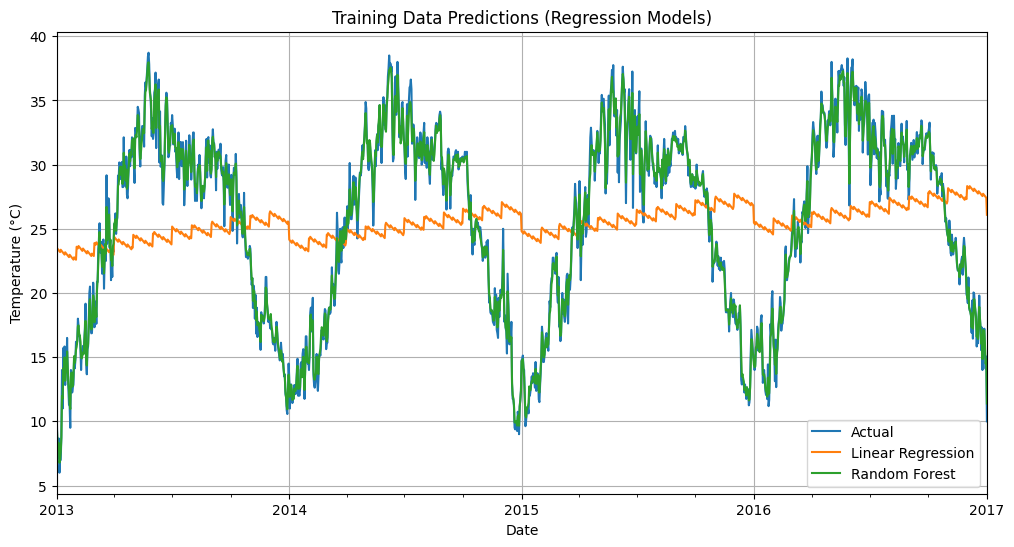

Linear Regression MSE: 52.4919732074845
Random Forest MSE: 0.3517813778952978


In [11]:
# Линейная регрессия
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_train)

# Случайный лес
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_train)

# Визуализация
plt.figure(figsize=(12, 6))
ts_train.plot(label='Actual')
plt.plot(ts_train.index, lr_pred, label='Linear Regression')
plt.plot(ts_train.index, rf_pred, label='Random Forest')
plt.title('Training Data Predictions (Regression Models)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid()
plt.show()

# Сравнение MSE
print(f"Linear Regression MSE: {mean_squared_error(y_train, lr_pred)}")
print(f"Random Forest MSE: {mean_squared_error(y_train, rf_pred)}")

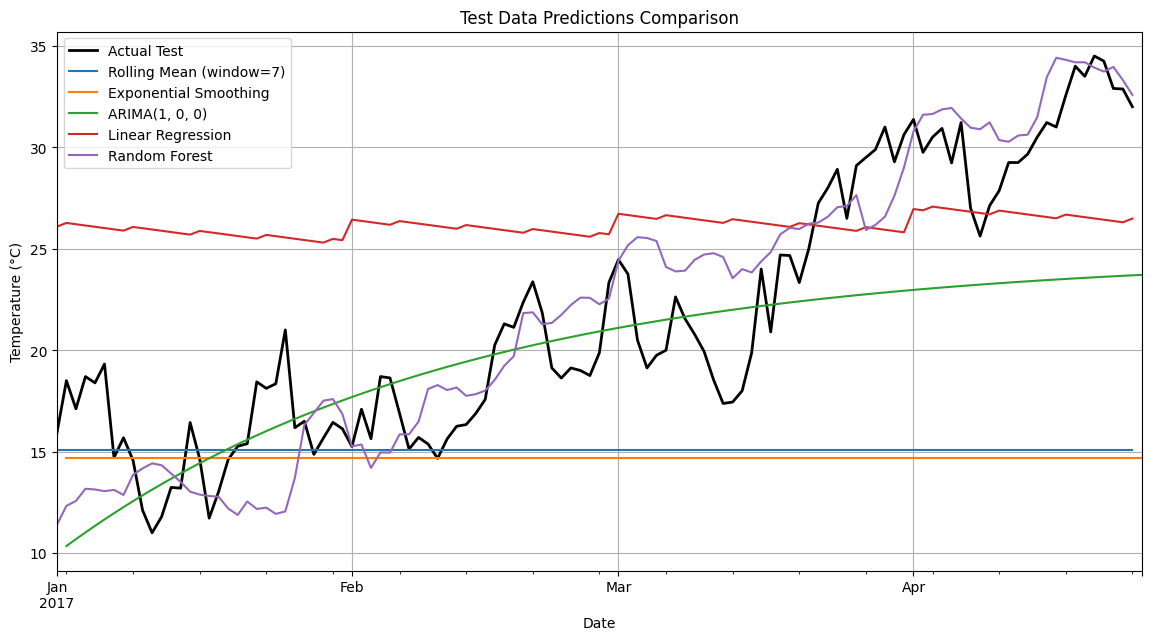


Test MSE Scores:
Rolling Mean: 84.0248
Exponential Smoothing: 89.2875
ARIMA: 21.8888
Linear Regression: 57.1698
Random Forest: 9.9652

Model Performance Comparison:
                   Model   Test MSE
4          Random Forest   9.965220
2                  ARIMA  21.888766
3      Linear Regression  57.169845
0           Rolling Mean  84.024817
1  Exponential Smoothing  89.287522


In [12]:
# 1. Прогнозирование временными рядами моделями на тестовых данных

# Скользящее среднее (используем последние значения из train)
rolling_test_pred = pd.Series([ts_train[-window_size:].mean()] * len(ts_test), index=ts_test.index)

# Экспоненциальное сглаживание
exp_test_pred = fit_exp.forecast(len(ts_test))

# ARIMA
arima_test_pred = fit_arima.forecast(len(ts_test))

# 2. Прогнозирование моделями регрессии
lr_test_pred = lr.predict(X_test)
rf_test_pred = rf.predict(X_test)

# 3. Визуализация всех прогнозов на тестовых данных
plt.figure(figsize=(14, 7))
ts_test.plot(label='Actual Test', color='black', linewidth=2)
rolling_test_pred.plot(label=f'Rolling Mean (window={window_size})')
exp_test_pred.plot(label='Exponential Smoothing')
arima_test_pred.plot(label='ARIMA(1, 0, 0)')
plt.plot(ts_test.index, lr_test_pred, label='Linear Regression')
plt.plot(ts_test.index, rf_test_pred, label='Random Forest')
plt.title('Test Data Predictions Comparison')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid()
plt.show()

# 4. Сравнение MSE на тестовых данных
print("\nTest MSE Scores:")
print(f"Rolling Mean: {mean_squared_error(ts_test, rolling_test_pred):.4f}")
print(f"Exponential Smoothing: {mean_squared_error(ts_test, exp_test_pred):.4f}")
print(f"ARIMA: {mean_squared_error(ts_test, arima_test_pred):.4f}")
print(f"Linear Regression: {mean_squared_error(ts_test, lr_test_pred):.4f}")
print(f"Random Forest: {mean_squared_error(ts_test, rf_test_pred):.4f}")

# 5. Сравнение в таблице
results = pd.DataFrame({
    'Model': ['Rolling Mean', 'Exponential Smoothing', 'ARIMA', 
              'Linear Regression', 'Random Forest'],
    'Test MSE': [
        mean_squared_error(ts_test, rolling_test_pred),
        mean_squared_error(ts_test, exp_test_pred),
        mean_squared_error(ts_test, arima_test_pred),
        mean_squared_error(ts_test, lr_test_pred),
        mean_squared_error(ts_test, rf_test_pred)
    ]
}).sort_values('Test MSE')

print("\nModel Performance Comparison:")
print(results)

In [13]:
best_arima_mse = float('inf')
for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                model = ARIMA(ts_train, order=(p,d,q))
                fit = model.fit()
                pred = fit.forecast(len(ts_test))
                mse = mean_squared_error(ts_test, pred)
                if mse < best_arima_mse:
                    best_arima_mse = mse
                    best_order = (p,d,q)
            except:
                continue
                
print(f"\nBest ARIMA order: {best_order}, MSE: {best_arima_mse:.4f}")

c:\Users\Администратор\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Администратор\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Администратор\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Администратор\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Администратор\AppDa


Best ARIMA order: (1, 0, 0), MSE: 21.8888
